# Computational Thermofluid Dynamics - Chapter 2

Technical University of Munich, Professur für Thermofluiddynamik - Pr. Polifke

Created: 04/2024 | J. Yao, N. Garcia, G. Varillon

Revised: 10/2025 | A.Keles

==============================================================================================

# Finite Differences
The 2D steady heat equation reads:
$$
\frac{\partial}{\partial x}(\lambda\frac{\partial T}{\partial x}) + \frac{\partial}{\partial y}(\lambda\frac{\partial T}{\partial y}) = 0
$$

# Stage 1 — Derivation of Finite Difference Scheme

Derive a **second-order accurate Finite Difference (FD)** scheme for the **2D steady-state heat equation** with **constant thermal conductivity** $\lambda$.  
Assume **Dirichlet boundary conditions** are applied on all sides of the domain.

Your task:
1. Start from the continuous governing equation  
   $$
   \frac{\partial}{\partial x}\!\left(\lambda \frac{\partial T}{\partial x}\right)
   + \frac{\partial}{\partial y}\!\left(\lambda \frac{\partial T}{\partial y}\right) = 0
   $$
2. Apply **central differencing** to discretize spatial derivatives.  
3. Present your **discrete equation** in **LaTeX format** below.


$$T_e \approx T_p + \Delta x \frac{dT}{dx} + \frac{(\Delta x)^2}{2} \frac{d^2T}{dx^2} + \frac{(\Delta x)^3}{6} \frac{d^3T}{dx^3} $$
$$T_w \approx T_p - \Delta x \frac{dT}{dx} + \frac{(\Delta x)^2}{2} \frac{d^2T}{dx^2} - \frac{(\Delta x)^3}{6} \frac{d^3T}{dx^3} $$
$$T_e + T_w = 2T_p + 2\frac{(\Delta x)^2}{2} \frac{d^2T}{dx^2}  $$
$$\frac{d^2T}{dx^2} = \frac{T_e - 2T_p + T_w}{(\Delta x)^2} $$
$$\frac{d^2T}{dy^2} = \frac{T_n - 2T_p + T_s}{(\Delta y)^2} $$
$$\lambda\frac{T_e - 2T_p + T_w}{(\Delta x)^2} + \lambda \frac{T_n - 2T_p + T_s}{(\Delta y)^2} = 0 $$
$$T_p(2\lambda)\left(\frac{1}{(\Delta x)^2} +\frac{1}{(\Delta y)^2} \right) = T_e\frac{\lambda}{(\Delta x)^2} + T_w\frac{\lambda}{(\Delta x)^2} + T_n\frac{\lambda}{(\Delta y)^2} + T_s\frac{\lambda}{(\Delta y)^2} $$
$$a_pT_p = a_e T_e + a_w T_w + a_n T_n + a_s T_s $$
$$a_pT_p - a_e T_e - a_w T_w - a_n T_n - a_s T_s = 0 $$
$$\mathbf{A} \vec{T} = \vec{b}$$

# Stage 2 — Implementation of 2D Steady-State Heat Conduction Solver

Using the provided class templates, implement a **2D steady-state heat conduction solver** with **Dirichlet, Robin and Neumann boundary conditions**.  
The solver should assemble and solve the linear system corresponding to the discretized finite difference equations derived in **Stage 1**.

Note that: The corner nodes are assigned as follows for this exercise:

SouthWest, NorthWest -> West

SouthEast, NorthEast -> East

Later in Finite Volume exercise, we will learn how to discretize them more precisely!

In [55]:
import numpy as np
import matplotlib.pyplot as plt
class Source:
    def __init__(self, location, is_active, q_dot):
        self.location = location # physical location of the point source, not index
        self.is_active = is_active # whether the point source is active
        self.q_dot = q_dot # intensity of the point source

class SteadyHeat2D:
    def __init__(self, Lx, Ly, dimX, dimY, source):
        self.l = Lx # domain length in x
        self.h = Ly # domain length in y
        self.dimX = dimX # number of nodes in x
        self.dimY = dimY # number of nodes in y

        self.source_location = source.location
        self.source_active = source.is_active

        # Add features for a source (location -> index)

        # Initialize these values
        # grid spacing
        self.dx = self.l / self.dimX
        self.dy = self.h / self.dimY
        # linear system placeholders
        self.A = np.zeros((self.dimY * self.dimX, self.dimY * self.dimX))
        self.b = np.zeros((self.dimY * self.dimX))

    # build the linear system
    def set_inner(self):
        """
        Assemble coefficient matrix A and RHS vector b

        If a point source is active, add its contribution
        to the corresponding node in the RHS vector.
        """
        a_p = 2 * ( 1 / self.dx ** 2 + 1 / self.dy ** 2)
        a_w = a_e = 1 / self.dx ** 2
        a_s = a_n = 1 / self.dy ** 2
        for j in np.arange(1, self.dimY - 1):
            for i in np.arange(1, self.dimX - 1):
                # This is the most important line of code 
                # We are converting XY grind into a a flattened vector
                k = j * self.dimX + i
                self.A[k, k] = a_p
                # Neighbors get negative coefficients
                self.A[k, k-1] = -a_w
                self.A[k, k+1] = -a_e
                self.A[k, k - self.dimX] = -a_n
                self.A[k, k + self.dimX] = -a_s

    # set the boundary conditions
    # south
    def set_south(self, bc_type, T_d=0.0, q=0.0, alpha = 0.0, T_inf=0.0):
        """
        Apply south boundary condition.

        Parameters
        ----------
        bc_type : str
            Type of boundary condition ('D', 'N', 'R')
        T_d : float
            Prescribed temperature (for Dirichlet)
        q : float
            Prescribed heat flux (for Neumann)
        alpha : float
            Convection coefficient (for Robin)
        T_inf : floatn bou
            Ambient temperature (for Robin)
        """
        if bc_type == 'D':
            j = self.dimY - 1
            i = np.arange(0, self.dimX)
            for i_idx in i:
                k = j * self.dimX + i_idx
                self.A[k, :] = 0.0
                self.A[k, k] = 1.0
                # We can set the temperature like this, because the coefficient in A matrix is 1.
                self.b[k] = T_d 
        # Von Neumann condition
        elif bc_type == 'N':
            # 2nd order accurate downwind
            a_p = 3. / (2 * self.dy ** 2)
            a_n = -2. / (self.dy ** 2)
            a_nn = 1. / (2 * self.dy ** 2)
            j = self.dimY - 1
            i = np.arange(0, self.dimX)
            for i_idx in i:
                k = j * self.dimX + i_idx
                self.A[k, k] = a_p
                # Point directly above it
                self.A[k, k - self.dimX] = a_n
                # 2 points above
                self.A[k, k - 2*self.dimX] = a_nn
                # Heat flux
                self.b[k] = -q / self.dy
            
                
    def set_north(self, bc_type, T_d=0.0, q=0.0, alpha = 0.0, T_inf=0.0):
        """
        Apply north boundary condition.

        Parameters
        ----------
        bc_type : str
            Type of boundary condition ('D', 'N', 'R')
        T_d : float
            Prescribed temperature (for Dirichlet)
        q : float
            Prescribed heat flux (for Neumann)
        alpha : float
            Convection coefficient (for Robin)
        T_inf : float
            Ambient temperature (for Robin)
        """
        # Dirichlet condition
        if bc_type == 'D':
            j = 0
            i = np.arange(0, self.dimX)
            for i_idx in i:
                k = j * self.dimX + i_idx
                self.A[k, :] = 0.0 
                self.A[k, k] = 1.0
                self.b[k] = T_d 
        # Robin condition
        elif bc_type == 'R':
            # 2nd order accurate upwind
            a_p = 3. + 2 * self.dy * alpha 
            a_s = -4.
            a_ss = 1.
            j = 0
            i = np.arange(0, self.dimX)
            for i_idx in i:
                k = j * self.dimX + i_idx
                self.A[k, k] = a_p
                # Point directly below it
                self.A[k, k + self.dimX] = a_s
                # 2 points below
                self.A[k, k + 2 * self.dimX] = a_ss
                # Heat flux
                self.b[k] = T_inf * 2 * self.dy * alpha 
        
    def set_east(self, bc_type, T_d=0.0, q=0.0, alpha = 0.0, T_inf=0.0):
        """
        Apply east boundary condition.

        Parameters
        ----------
        bc_type : str
            Type of boundary condition ('D', 'N', 'R')
        T_d : float
            Prescribed temperature (for Dirichlet)
        q : float
            Prescribed heat flux (for Neumann)
        alpha : float
            Convection coefficient (for Robin)
        T_inf : float
            Ambient temperature (for Robin)
        """
        # Dirichlet condition
        if bc_type == 'D':
            j = np.arange(0, self.dimY)
            i = self.dimX - 1
            for j_idx in j:
                k = j_idx * self.dimX + i
                self.A[k, :] = 0.0
                self.A[k, k] = 1.0
                self.b[k] = T_d 
        # Robin condition
        elif bc_type == 'R':
            # 2nd order accurate upwind
            a_p = 3. + 2 * self.dx * alpha 
            a_w = -4.
            a_ww = 1.
            j = np.arange(0, self.dimY)
            i = self.dimX - 1
            for j_idx in j:
                k = j_idx * self.dimX + i
                self.A[k, k] = a_p
                # Point directly below it
                self.A[k, k-1] = a_w
                # 2 points below
                self.A[k, k-2] = a_ww
                # Heat flux
                self.b[k] = T_inf * 2 * self.dx * alpha 
                
    def set_west(self, bc_type, T_d=0.0, q=0.0, alpha = 0.0, T_inf=0.0):
        """
        Apply west boundary condition.

        Parameters
        ----------
        bc_type : str
            Type of boundary condition ('D', 'N', 'R')
        T_d : float
            Prescribed temperature (for Dirichlet)
        q : float
            Prescribed heat flux (for Neumann)
        alpha : float
            Convection coefficient (for Robin)
        T_inf : float
            Ambient temperature (for Robin)
        """
        if bc_type == 'D':
            j = np.arange(0, self.dimY)
            i = 0
            for j_idx in j:
                k = j_idx * self.dimX + i
                self.A[k, :] = 0.0
                self.A[k, k] = 1.0
                self.b[k] = T_d 

    # solve the linear system
    def solve(self):
        """
        Solve the assembled linear system A·T = b
        using np.lingalg.solve()
        and reshape the temperature field to 2D.
        """
        self.set_inner()
        temp_sol = np.linalg.solve(self.A, self.b)
        return temp_sol.reshape((self.dimY, self.dimX))

    # visualize the result
    def plot(self, TemperatureField):
        """
        Visualize the temperature field as a 2D contour or heatmap.
        """
        plt.imshow(TemperatureField, cmap='viridis', interpolation='none')
        plt.colorbar(label='Temperature (K)')
        plt.title('Temperature Field')
        plt.show()
        


# Stage 3 — Test Case 1: All Dirichlet Boundary Conditions

Validate your solver by testing a simple case with **Dirichlet boundaries on all sides**.  
No internal heat source is active. The temperature field should show a smooth gradient
between the hot and cold boundaries.

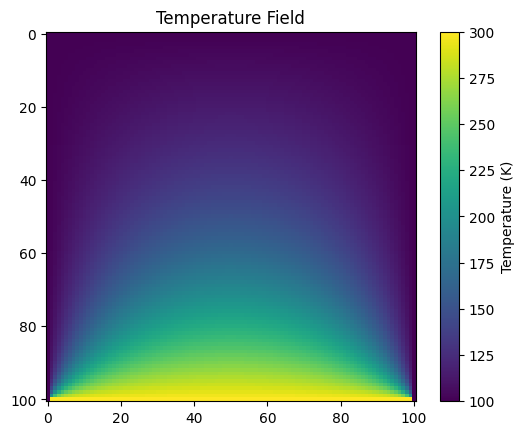

In [52]:
# ================================================================
# Test Case 1 — All Dirichlet Boundary Conditions
# ================================================================

# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (inactive for this test)
source = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)

# Initialize solver
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)

# Apply boundary conditions
heat.set_south('D', T_d=300)   # Bottom boundary (hot)
heat.set_north('D', T_d=100)   # Top boundary
heat.set_east('D',  T_d=100)   # Right boundary
heat.set_west('D',  T_d=100)   # Left boundary



# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)


Let's look at the terms in the coefficient matrix

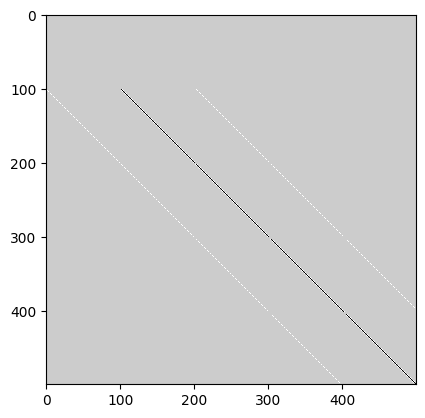

In [21]:
plt.imshow(heat.A[:500, :500], cmap='gray_r', interpolation='none')


# Stage 3 — Test Case 2 : Mixed Boundary Conditions

Validate your solver by running a case with **mixed boundary types** to verify correct handling of  
**Dirichlet**, **Neumann**, and **Robin** conditions simultaneously.  
No internal heat source is active.

The temperature field should smoothly transition from the fixed west boundary to the other sides.


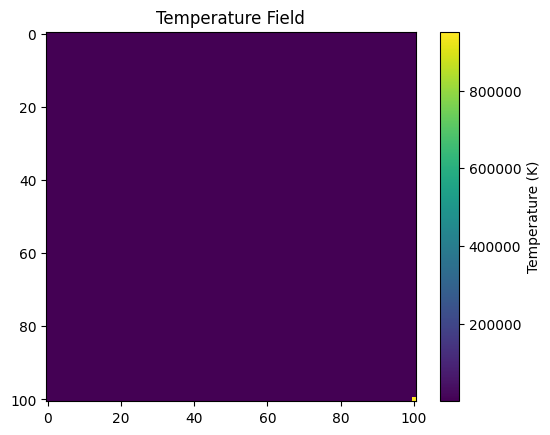

In [57]:
# ================================================================
# Test Case 2 — Mixed Boundary Conditions - Original Case
# ================================================================

# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (inactive for this test)
source = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)

# Apply boundary conditions
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)
heat.set_south('N', q = 0.0)
heat.set_north('R', alpha = 1.0, T_inf = 100)
heat.set_east('R', alpha = 1.0, T_inf = 100)
heat.set_west('D', T_d = 300)

# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)

# Stage 3 — Test Case 3 : Mixed Boundary Conditions with Point Source is Active

Validate your solver by running a case with **mixed boundary types** to verify correct handling of  
**Dirichlet**, **Neumann**, and **Robin** conditions simultaneously.  
Internal heat source is active.



In [ ]:
# ================================================================
# Test Case 3 — Mixed Boundary Conditions with Point Source is Active
# ================================================================
# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (inactive for this test)
source = Source(location=[0.5, 0.95], is_active=True, q_dot=200)

# Apply boundary conditions
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)
heat.set_south('N', q = 0.0)
heat.set_north('R', alpha = 1.0, T_inf = 100)
heat.set_east('R', alpha = 1.0, T_inf = 100)
heat.set_west('D', T_d = 300)

# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)

# Stage 4 — Variable Thermal Conductivity (Optional)

Extend your steady-state heat conduction solver to handle **spatially varying thermal conductivity** λ(x, y).  
Do not change anything above — start working **independently** in the cell below cell.  
A new class can be written from scratch, you may copy the class above and implement the necessary changes.

Eq. (2.50) should now be discretized by considering λ depending on space.


In [ ]:
# New class that handles λ(x,y)

# Test Case for new class
